# Importings

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[ 1.15464314,  2.10068854],
       [-6.44852937, -6.88878247],
       [-2.62174998,  2.02695323],
       ...,
       [ 2.30515648,  2.73266653],
       [-5.52702164,  2.82637278],
       [-1.86805447,  2.36245904]])

In [4]:
y

array([1, 2, 0, 1, 1, 1, 0, 0, 2, 2, 2, 2, 0, 0, 2, 2, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 2, 2, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 2, 2, 1, 1, 0, 0, 2, 1, 1, 1, 0, 2, 2, 0, 2, 2, 0,
       2, 1, 1, 2, 2, 0, 1, 2, 2, 1, 1, 0, 0, 1, 1, 1, 2, 0, 2, 2, 0, 2,
       1, 2, 1, 0, 0, 0, 0, 1, 1, 1, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2, 1,
       1, 1, 2, 2, 0, 1, 1, 0, 1, 1, 2, 2, 1, 1, 0, 0, 1, 1, 0, 1, 2, 2,
       2, 1, 2, 2, 2, 0, 0, 2, 2, 1, 2, 1, 1, 1, 0, 1, 1, 2, 0, 2, 0, 0,
       2, 1, 1, 2, 2, 2, 2, 1, 1, 1, 0, 0, 2, 1, 1, 2, 1, 0, 0, 0, 0, 0,
       0, 2, 2, 2, 1, 2, 1, 0, 2, 1, 1, 0, 2, 0, 0, 0, 1, 2, 0, 0, 2, 0,
       2, 2, 2, 2, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 1, 0, 1, 2, 1, 0, 1, 1,
       0, 0, 2, 2, 0, 1, 2, 1, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0, 0, 2,
       2, 2, 1, 0, 0, 0, 2, 1, 2, 2, 1, 2, 0, 2, 2, 1, 2, 2, 0, 0, 1, 0,
       2, 2, 0, 0, 1, 0, 1, 1, 0, 2, 2, 2, 1, 2, 1, 2, 0, 0, 2, 1, 0, 0,
       1, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 1,

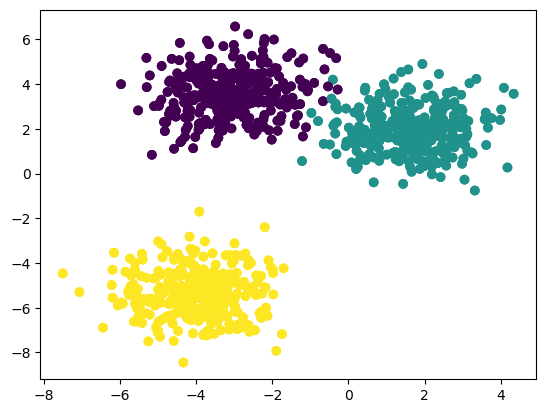

In [11]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

## c=y
#The c argument specifies the color of each point in the scatter plot.

# y is usually a label array or target variable, where each element corresponds to a data point’s class or category.

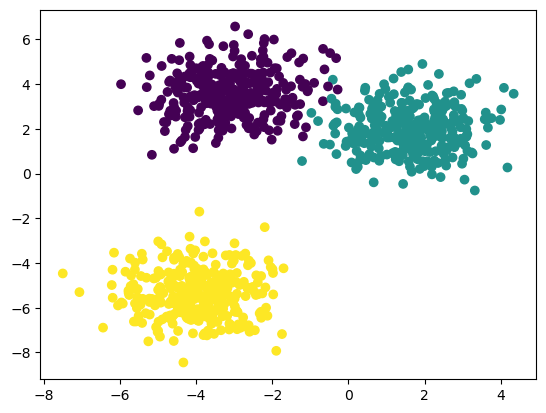

In [15]:
plt.scatter(X[:,0],X[:,1],c=y, cmap = 'viridis')
plt.show()

In [16]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [19]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [23]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [25]:
from sklearn.cluster import KMeans

In [26]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

In [14]:
wcss

[1340.0000000000002,
 524.4328136537987,
 385.7730002537804,
 295.9153865420301,
 236.0529288952293,
 196.60383426713298,
 173.891829825547,
 153.97303183876005,
 147.14995672320484,
 132.36544544456498]

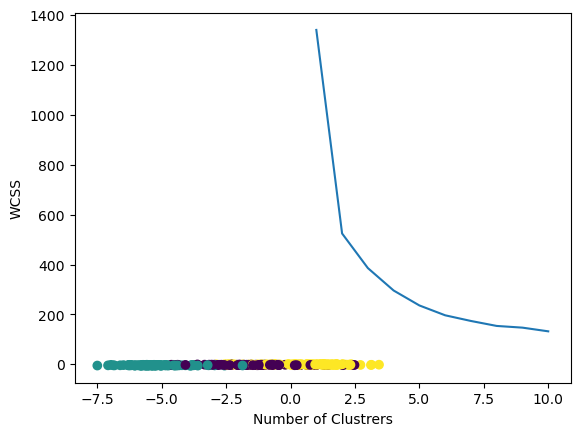

In [42]:
## plot elbow curve
plt.plot(range(1,11),wcss)
# plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [16]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [17]:
kmeans.fit_predict(X_train_scaled)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([1, 1, 1, 0, 1, 0, 2, 1, 2, 2, 0, 1, 1, 0, 2, 0, 2, 2, 1, 0, 0, 0,
       1, 1, 0, 2, 2, 0, 1, 1, 1, 2, 0, 1, 0, 0, 2, 1, 1, 1, 0, 1, 1, 0,
       1, 2, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 2, 0, 2, 2, 1, 0, 0, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 2, 2, 1, 1, 1, 1, 1, 2, 0, 0, 2, 2, 0,
       1, 0, 1, 2, 0, 1, 0, 1, 0, 2, 2, 2, 2, 0, 2, 2, 1, 0, 1, 2, 0, 1,
       0, 1, 2, 2, 1, 2, 2, 0, 1, 1, 2, 1, 1, 2, 0, 1, 1, 2, 2, 1, 0, 2,
       2, 0, 0, 2, 2, 0, 1, 2, 0, 2, 2, 1, 2, 2, 2, 0, 1, 2, 0, 0, 0, 0,
       0, 1, 1, 2, 1, 2, 0, 1, 2, 0, 2, 1, 2, 2, 2, 1, 0, 0, 2, 2, 1, 1,
       1, 1, 0, 0, 2, 1, 2, 2, 1, 1, 0, 1, 0, 2, 0, 1, 2, 2, 0, 1, 2, 2,
       0, 1, 2, 0, 2, 2, 0, 1, 0, 0, 0, 2, 0, 1, 0, 2, 2, 2, 1, 1, 2, 1,
       0, 0, 2, 1, 2, 2, 1, 2, 1, 2, 1, 2, 0, 0, 2, 2, 2, 1, 0, 2, 2, 2,
       1, 2, 0, 2, 0, 1, 0, 0, 1, 1, 2, 1, 2, 2, 1, 1, 1, 1, 0, 2, 0, 2,
       2, 0, 2, 1, 2, 2, 1, 0, 2, 0, 0, 1, 1, 1, 0,

In [18]:
y_pred=kmeans.predict(X_test_scaled)

In [19]:
y_pred

array([0, 2, 2, 0, 2, 2, 0, 1, 2, 2, 2, 1, 2, 0, 0, 2, 0, 1, 0, 1, 2, 0,
       1, 2, 0, 0, 0, 2, 2, 0, 0, 2, 1, 1, 0, 1, 2, 2, 2, 0, 1, 1, 0, 2,
       1, 0, 2, 1, 2, 0, 1, 2, 1, 0, 1, 2, 0, 1, 2, 1, 2, 2, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 2, 1, 1, 1, 0, 0, 1, 2, 0, 2, 0, 1, 1, 1, 1,
       2, 1, 0, 0, 0, 0, 1, 2, 0, 1, 0, 2, 1, 2, 2, 1, 0, 0, 0, 2, 1, 2,
       1, 0, 2, 2, 0, 2, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 1, 2, 2, 2, 2, 1,
       2, 1, 2, 1, 0, 0, 0, 1, 1, 2, 1, 0, 1, 2, 0, 0, 0, 2, 1, 0, 2, 1,
       2, 1, 1, 1, 2, 2, 0, 1, 2, 1, 2, 0, 1, 1, 0, 0, 2, 1, 2, 0, 1, 2,
       2, 1, 2, 2, 1, 1, 0, 2, 2, 2, 1, 1, 1, 2, 0, 2, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 2, 2, 1, 0, 1, 0, 2, 0, 0, 0, 0, 2, 1, 2, 0, 0, 0, 2,
       1, 1, 2, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 2,
       2, 2, 1, 2, 0, 1, 1, 2, 2, 2, 2, 2, 2, 1, 0, 1, 1, 2, 0, 2, 2, 2,
       2, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 0, 2, 2, 2, 2, 1, 2, 2, 1, 2, 0,
       1, 1, 0, 0, 2, 2, 1, 2, 2, 0, 2, 2, 0, 2, 0,

In [29]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)
plt.show()

NameError: name 'y_pred' is not defined

In [21]:
## Validating the k value
## kneelocator
## Silhoutee scoring
## Dunn Index

In [31]:
## kneelocator
!pip install kneed

In [32]:
from kneed import KneeLocator

In [33]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [34]:
kl.elbow

3

In [39]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [41]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_) ##kmeans.labels_: The cluster assignments from the fitted model.
    silhouette_coefficients.append(score)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

In [ ]:
silhouette_coefficients

[np.float64(0.7005613926892843),
 np.float64(0.823706727707465),
 np.float64(0.6758136427137829),
 np.float64(0.5309837024729261),
 np.float64(0.38498801561210066),
 np.float64(0.36943622853772556),
 np.float64(0.33832725832564414),
 np.float64(0.3260843289913775),
 np.float64(0.32651616642282927)]

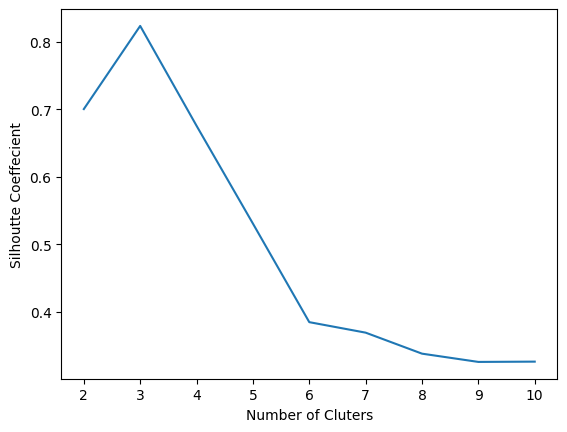

In [ ]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()